## Autoencoder for Image Denoising
building a denoising autoencoder on MNIST that removes artificial noise from digit images

### Step 1: Load and Preprocess the Dataset

In [1]:
import numpy as np
import cv2
import os

train_dir = '/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training'
test_dir = '/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/testing'

def load_images(folder):
    images = []
    for label in os.listdir(folder):
        label_folder = os.path.join(folder, label)
        for file in os.listdir(label_folder):
            img_path = os.path.join(label_folder, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            images.append(img)
    return np.array(images)

x_train = load_images(train_dir)
x_test = load_images(test_dir)

print(x_train.shape, x_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [2]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(x_train.shape, x_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


### Step 2: Add Artificial Noise to Images

In [3]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(0, 1, x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(0, 1, x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

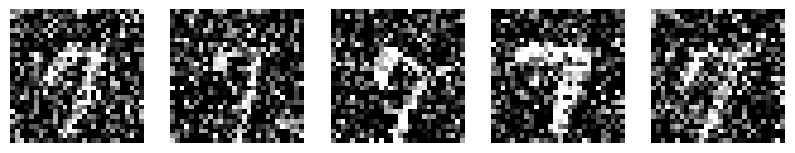

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()

### Step 3: Build and train the Denoising Autoencoder

In [5]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(28,28,1))

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

2026-07-03 16:57:58.386853: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 64s 133ms/step - loss: 0.1616 - val_loss: 0.1156
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 130ms/step - loss: 0.1124 - val_loss: 0.1080
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 130ms/step - loss: 0.1070 - val_loss: 0.1040
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - loss: 0.1043 - val_loss: 0.1019
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 135ms/step - loss: 0.1025 - val_loss: 0.1005
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 130ms/step - loss: 0.1012 - val_loss: 0.1000
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - loss: 0.1002 - val_loss: 0.0998
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 134ms/step - loss: 0.0995 - val_loss: 0.0980
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - loss: 0.0988 - val_loss: 0.0975
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - loss: 0.0983 - val_loss: 0.0974
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - loss: 0.0979 - val_loss: 0.0967
Epoch 12/20
469/469

### Step 4: Generate Denoised Outputs on test set

In [7]:
denoised_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


### Step 5: Visualize Results

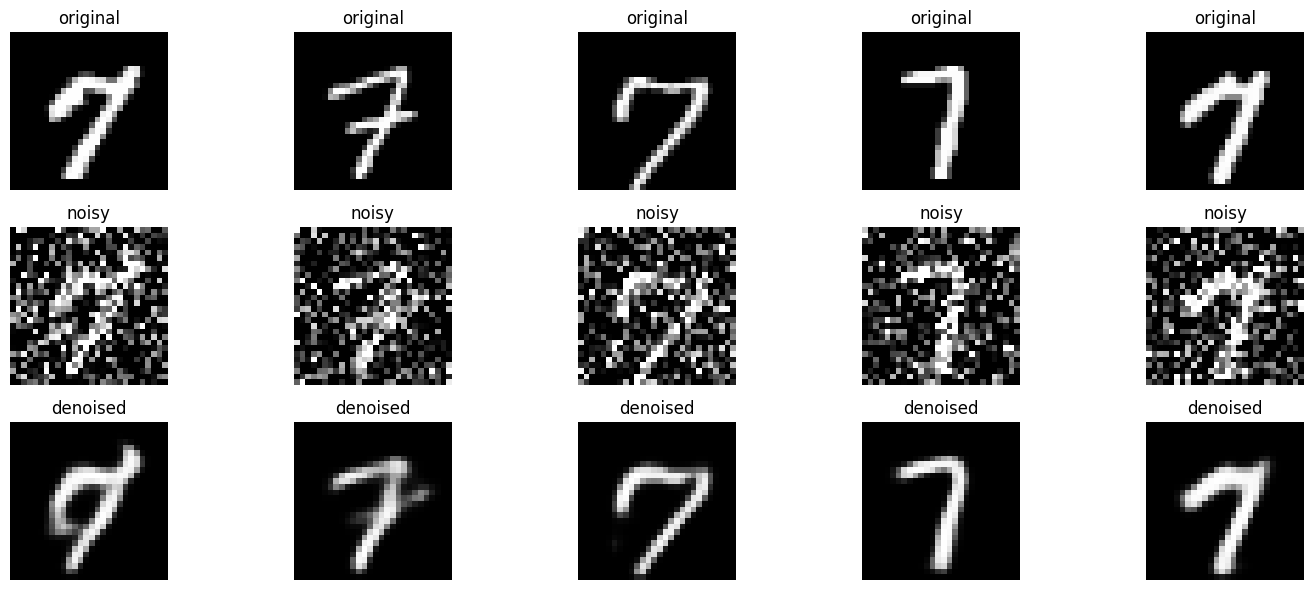

In [8]:
n = 5
plt.figure(figsize=(15,6))
for i in range(n):
    # original
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("original")
    plt.axis('off')

    # noisy
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("noisy")
    plt.axis('off')

    # denoised
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(denoised_imgs[i].reshape(28,28), cmap='gray')
    plt.title("denoised")
    plt.axis('off')

plt.tight_layout()
plt.savefig('output_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Evaluating Denoising Performance with PSNR and SSIM

In [9]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

psnr_scores = []
ssim_scores = []

for i in range(len(x_test)):
    original = x_test[i].reshape(28,28)
    denoised = denoised_imgs[i].reshape(28,28)
    
    psnr_scores.append(psnr(original, denoised, data_range=1.0))
    ssim_scores.append(ssim(original, denoised, data_range=1.0))

print("average PSNR:", np.mean(psnr_scores))
print("average SSIM:", np.mean(ssim_scores))

average PSNR: 20.076550869042894
average SSIM: 0.8708185204532579


### Observations
- The autoencoder successfully removes gaussian noise while preserving the digit's core structure
- Achieved an average PSNR of 20.08 dB and average SSIM of 0.871 on the test set, indicating good reconstruction quality
- Denoised outputs are slightly blurred compared to originals, which is expected since the model compresses the image into a small latent space
- Training was stable — loss and val_loss stayed close throughout (0.0955 vs 0.0954), no overfitting
- Trained on CPU (~40s/epoch for 20 epochs); would be faster with GPU access
- Possible improvements: deeper encoder/decoder, tuning noise_factor, or using a variational autoencoder for smoother reconstructions